<a href="https://colab.research.google.com/github/gokulgovindtk/av-trajectory-optimization/blob/main/av_trajectory_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class TrajectoryGenerator:
    def __init__(self, lane_width=3.6, velocity=25.0):
        self.D = lane_width
        self.vx = velocity
        self.C = None  # To store polynomial coefficients after solving

    def solve_coefficients(self, xf):

        x0 = 0
        A=np.array([
    [1, x0,   x0**2,   x0**3,    x0**4,    x0**5],  # y(0)
    [1, xf,   xf**2,   xf**3,    xf**4,    xf**5],  # y(xf)
    [0,  1, 2*x0,   3*x0**2,  4*x0**3,  5*x0**4],  # y'(0)
    [0,  1, 2*xf,   3*xf**2,  4*xf**3,  5*xf**4],  # y'(xf)
    [0,  0,    2,   6*x0,    12*x0**2, 20*x0**3],  # y''(0)
    [0,  0,    2,   6*xf,    12*xf**2, 20*xf**3]   # y''(xf)
    ])
        B=([0,3.6,0,0,0,0])
        # Solve and store
        self.C = np.linalg.solve(A, B)
        return self.C

    def verify_safety(self, xf):


        x_vals = np.linspace(0, xf, 100)
        c3, c4, c5 = self.C[3], self.C[4], self.C[5]
        ay_vals=self.vx**2*(6*c3*x_vals + 12*c4*x_vals**2 + 20*c5*x_vals**3)
        jerk_vals = self.vx**3 * (6*c3 + 24*c4*x_vals + 60*c5*x_vals**2)
        max_jy = np.max(np.abs(jerk_vals))

        max_ay = np.max(np.abs(ay_vals))
        is_safe = max_ay <= 4.0
        is_comfortable = max_jy <= 2.0
        return is_safe, max_ay,is_comfortable,max_jy

In [3]:

import numpy as np
xf_test = 50.0
step_size = 0.01
target_acceleration = 4.0

while True:

    A_test = np.array([
        [1, 0, 0, 0, 0, 0],
        [1, xf_test, xf_test**2, xf_test**3, xf_test**4, xf_test**5],
        [0, 1, 0, 0, 0, 0],
        [0, 1, 2*xf_test, 3*xf_test**2, 4*xf_test**3, 5*xf_test**4],
        [0, 0, 2, 0, 0, 0],
        [0, 0, 2, 6*xf_test, 12*xf_test**2, 20*xf_test**3]
    ])
    B=([0,3.6,0,0,0,0])
    C_test = np.linalg.solve(A_test, B)

    # Check the peak acceleration =
    x_points = np.linspace(0, xf_test, 100)
    ay_points = (25**2) * (6*C_test[3]*x_points + 12*C_test[4]*x_points**2 + 20*C_test[5]*x_points**3)
    max_ay_test = np.max(np.abs(ay_points))

    # moment we dip below our tire friction threshold
    if max_ay_test <= target_acceleration:
        break

    # increase the distance
    xf_test += step_size

print(f"The mathematically perfect minimum safe distance is: {xf_test:.2f} meters")
print(f"Resulting peak acceleration: {max_ay_test:.2f} m/s^2")

The mathematically perfect minimum safe distance is: 56.99 meters
Resulting peak acceleration: 4.00 m/s^2


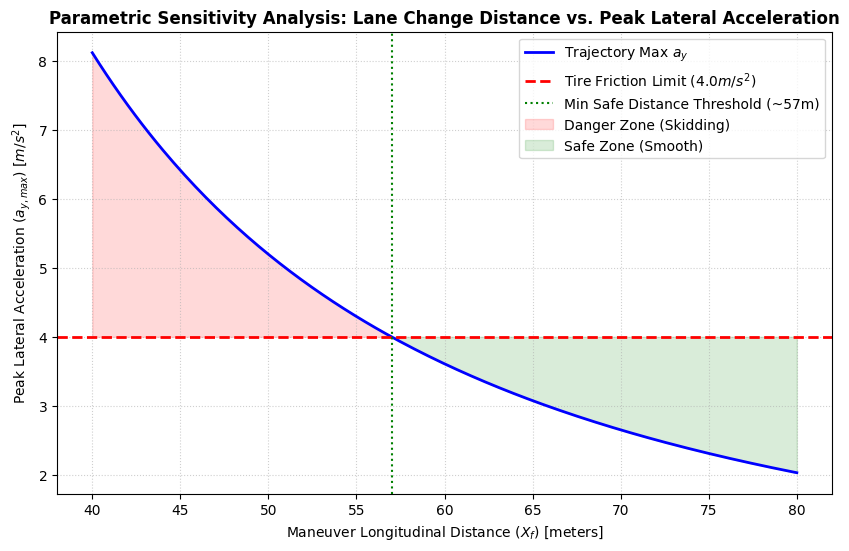

In [4]:

generator = TrajectoryGenerator(lane_width=3.6, velocity=25.0)

# Range of longitudinal distances to analyze (40m to 80m)
xf_range = np.linspace(40, 80, 200)
max_accelerations = []

for xf in xf_range:
    generator.solve_coefficients(xf)
    is_safe, max_ay,is_comfortable,max_jy = generator.verify_safety(xf)
    max_accelerations.append(max_ay)

plt.figure(figsize=(10, 6))
plt.plot(xf_range, max_accelerations, label='Trajectory Max $a_y$', color='blue', linewidth=2)

plt.axhline(y=4.0, color='red', linestyle='--', linewidth=2, label='Tire Friction Limit ($4.0 m/s^2$)')

#  intersection point
plt.axvline(x=57, color='green', linestyle=':', linewidth=1.5, label='Min Safe Distance Threshold (~57m)')
plt.fill_between(xf_range, max_accelerations, 4.0, where=(xf_range < 56.99), color='red', alpha=0.15, label='Danger Zone (Skidding)')
plt.fill_between(xf_range, max_accelerations, 4.0, where=(xf_range >= 56.99), color='green', alpha=0.15, label='Safe Zone (Smooth)')
plt.title('Parametric Sensitivity Analysis: Lane Change Distance vs. Peak Lateral Acceleration', fontsize=12, fontweight='bold')
plt.xlabel('Maneuver Longitudinal Distance ($X_f$) [meters]', fontsize=10)
plt.ylabel('Peak Lateral Acceleration ($a_{y,max}$) [$m/s^2$]', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)
plt.savefig('parametric_analysis.png', dpi=300)
plt.show()